In [68]:
import os
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_dir = Path("Deep-Learning-Project-Tuwaiq")
    if not repo_dir.is_dir():
        !git clone https://github.com/khaliddosari/Deep-Learning-Project-Tuwaiq.git
    os.chdir(repo_dir)

In [69]:
def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        if (base / "src" / "config.py").is_file():
            return base
    for child in sorted(c for c in start.iterdir() if c.is_dir()):
        if (child / "src" / "config.py").is_file():
            return child
    raise RuntimeError(f"Could not find the project root from {start}.")

ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq


In [70]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from src.config import IMG_SHAPE, NUM_CLASSES, SEED
from src.data import load_splits
from src.models import build_dense_model, validate_model
from src.utils import set_seed

set_seed(SEED)

data = load_splits()

print(data.summary())

X_train  (45000, 32, 32, 3)  float32
X_val    (5000, 32, 32, 3)   float32
X_test   (10000, 32, 32, 3)  float32
y_train  (45000,)            int32
y_val    (5000,)             int32
y_test   (10000,)            int32


In [72]:
HIDDEN_UNITS = [512, 512, 512]

LEARNING_RATE = 0.0001
BATCH_SIZE = 128
EPOCHS = 50

print("Selected architecture:", HIDDEN_UNITS)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Selected architecture: [512, 512, 512]
Learning rate: 0.0001
Batch size: 128
Epochs: 50


In [73]:
baseline_model = build_dense_model(
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
    optimizer="adam",
    seed=SEED,
    name="medium_baseline"
)

baseline_model.summary()

Model: "medium_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,103,818 (8.03 MB)

 Trainable params: 2,103,818 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
set_seed(SEED)

baseline_model = build_dense_model(
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    name="medium_baseline"
)

baseline_history = baseline_model.fit(
    data.X_train,
    data.y_train,
    validation_data=(data.X_val, data.y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787476905.081807   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3450989__.14


330/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3390 - loss: 1.8550

I0000 00:00:1787476906.921156   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3450989__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3431 - loss: 1.8441 - val_accuracy: 0.3994 - val_loss: 1.6931
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4189 - loss: 1.6380 - val_accuracy: 0.4308 - val_loss: 1.6060
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4483 - loss: 1.5546 - val_accuracy: 0.4490 - val_loss: 1.5562
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4717 - loss: 1.4927 - val_accuracy: 0.4608 - val_loss: 1.5209
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4905 - loss: 1.4425 - val_accuracy: 0.4756 - val_loss: 1.4958
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5062 - loss: 1.3996 - val_accuracy: 0.4834 - val_loss: 1.4762
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5191 - loss: 1.3611 - val_accuracy: 0.4868 - val_loss: 1.4606
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5339 - loss: 1.3257 - val_accuracy: 0.4906 - val

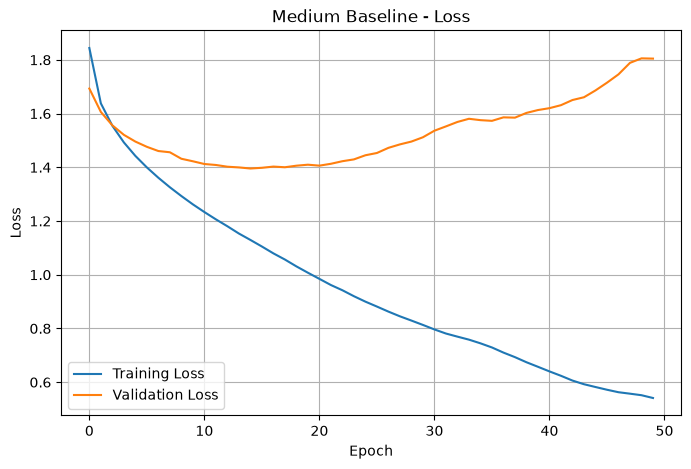

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Medium Baseline - Loss")
plt.legend()
plt.grid(True)
plt.show()

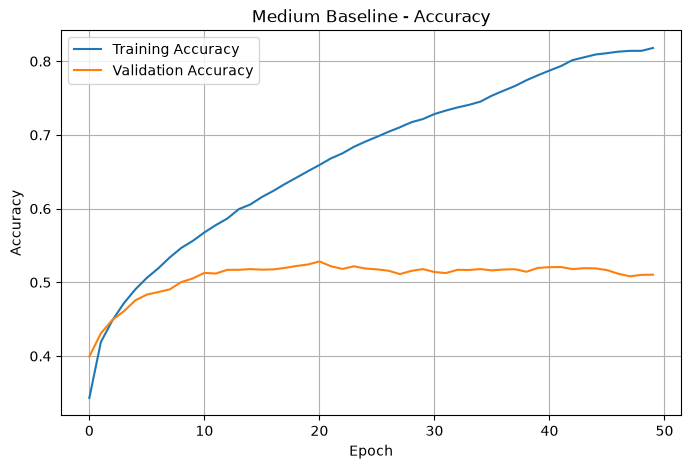

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Medium Baseline - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
best_val_acc = max(baseline_history.history["val_accuracy"])
best_val_acc_epoch = (
    baseline_history.history["val_accuracy"].index(best_val_acc) + 1
)

min_val_loss = min(baseline_history.history["val_loss"])
min_val_loss_epoch = (
    baseline_history.history["val_loss"].index(min_val_loss) + 1
)

final_train_acc = baseline_history.history["accuracy"][-1]
final_val_acc = baseline_history.history["val_accuracy"][-1]

final_train_loss = baseline_history.history["loss"][-1]
final_val_loss = baseline_history.history["val_loss"][-1]

print("===== MEDIUM BASELINE =====")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")
print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
print(f"Final Training Accuracy  : {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss      : {final_train_loss:.4f}")
print(f"Final Validation Loss    : {final_val_loss:.4f}")

===== MEDIUM BASELINE =====
Best Validation Accuracy : 0.5284
Best Validation Acc Epoch: 21
Minimum Validation Loss  : 1.3955
Minimum Val Loss Epoch   : 15
Final Training Accuracy  : 0.8180
Final Validation Accuracy: 0.5104
Final Training Loss      : 0.5412
Final Validation Loss    : 1.8046


### PART9-17

# Part 9 - Learning Rate Experiment

We test different learning rates while keeping the selected Medium architecture
[512, 512, 512] and all other hyperparameters unchanged.


In [78]:
# Load the same train/validation/test split used throughout the project

splits = load_splits()

X_train = splits.X_train
y_train = splits.y_train

X_val = splits.X_val
y_val = splits.y_val

X_test = splits.X_test
y_test = splits.y_test

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
X_val: (5000, 32, 32, 3)
X_test: (10000, 32, 32, 3)
y_train: (45000,)
y_val: (5000,)
y_test: (10000,)


In [79]:
# Part 9 - Learning Rate Experiment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt

# Fixed settings from the selected Medium architecture
HIDDEN_UNITS = [512, 512, 512]
BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATES = [0.01, 0.001, 0.0001]

print("Architecture:", HIDDEN_UNITS)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rates:", LEARNING_RATES)

Architecture: [512, 512, 512]
Batch size: 128
Epochs: 50
Learning rates: [0.01, 0.001, 0.0001]


In [80]:
def build_medium_model(learning_rate):

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [81]:
learning_rate_results = {}
learning_rate_histories = {}

for lr in LEARNING_RATES:

    print("\n" + "=" * 60)
    print(f"Training with Learning Rate = {lr}")
    print("=" * 60)

    # Fresh model = fresh weights
    model = build_medium_model(lr)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    learning_rate_histories[lr] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    learning_rate_results[lr] = {
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": final_train_acc,
        "Final Val Accuracy": final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Val Loss": final_val_loss
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
    print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Training with Learning Rate = 0.01


/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787476960.082576   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3532411__.14


345/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2560 - loss: 2.6662

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3293 - loss: 1.8576 - val_accuracy: 0.3928 - val_loss: 1.7143
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4086 - loss: 1.6527 - val_accuracy: 0.4368 - val_loss: 1.6037
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4367 - loss: 1.5695 - val_accuracy: 0.4418 - val_loss: 1.5671
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4619 - loss: 1.5028 - val_accuracy: 0.4544 - val_loss: 1.5508
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4812 - loss: 1.4553 - val_accuracy: 0.4518 - val_loss: 1.5386
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4949 - loss: 1.4151 - val_accuracy: 0.4724 - val_loss: 1.5077
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5072 - loss: 1.3747 - val_accuracy: 0.4620 - val_loss: 1.5250
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5183 - loss: 1.3422 - val_accuracy: 0.4620 - val_

I0000 00:00:1787477057.522264   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3695255__.14


335/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3391 - loss: 1.8535

I0000 00:00:1787477059.358648   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3695255__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3418 - loss: 1.8458 - val_accuracy: 0.4002 - val_loss: 1.6954
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4168 - loss: 1.6405 - val_accuracy: 0.4370 - val_loss: 1.6061
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4471 - loss: 1.5556 - val_accuracy: 0.4526 - val_loss: 1.5642
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4680 - loss: 1.4944 - val_accuracy: 0.4622 - val_loss: 1.5323
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4874 - loss: 1.4466 - val_accuracy: 0.4760 - val_loss: 1.4933
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5030 - loss: 1.4044 - val_accuracy: 0.4816 - val_loss: 1.4839
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5184 - loss: 1.3641 - val_accuracy: 0.4920 - val_loss: 1.4608
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5311 - loss: 1.3283 - val_accuracy: 0.5012 - val

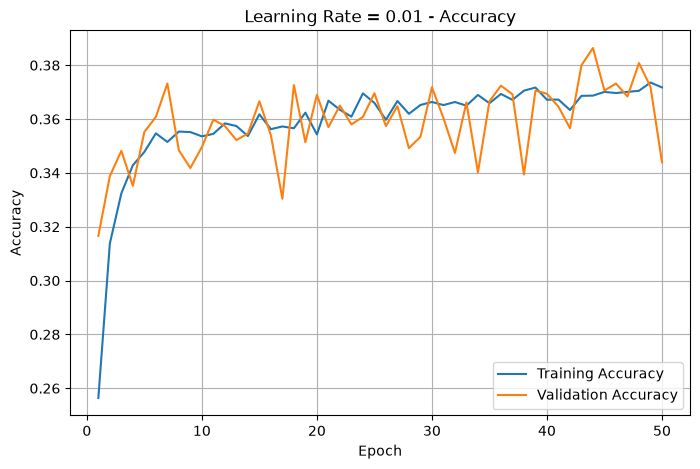

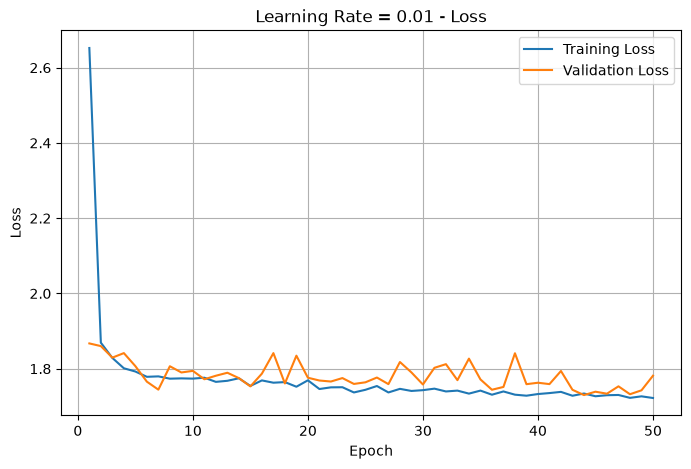

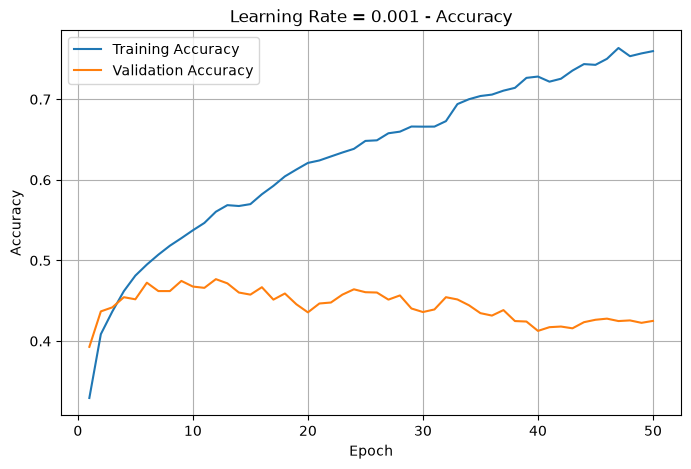

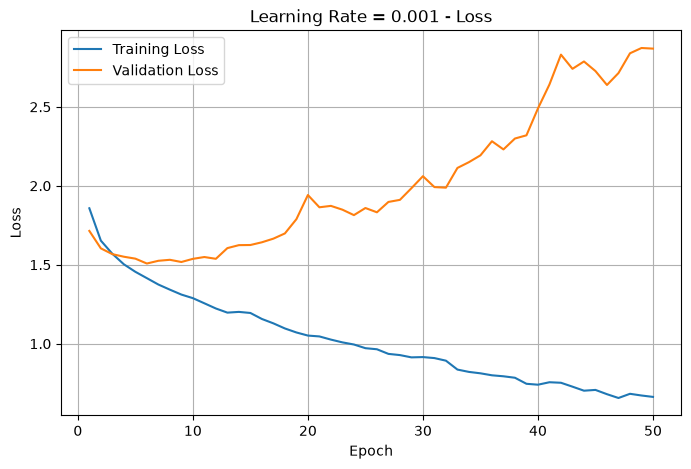

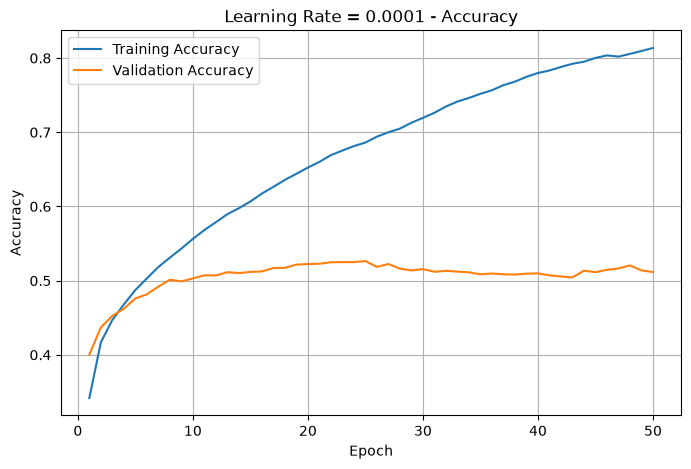

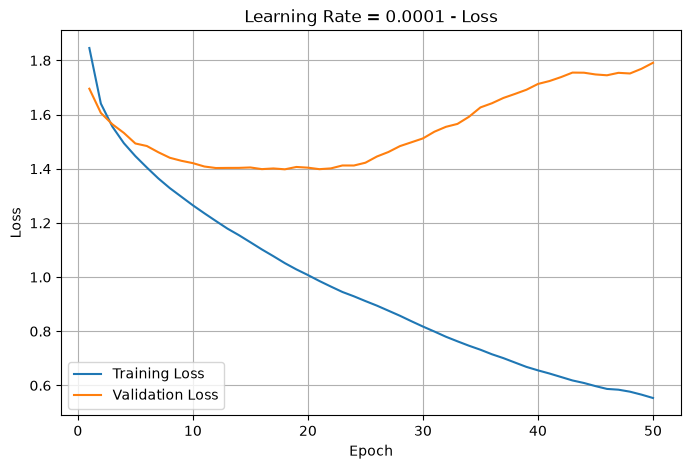

In [82]:
# Part 9 - Learning Curves for Each Learning Rate

for lr, history in learning_rate_histories.items():

    epochs_range = range(1, len(history["accuracy"]) + 1)

    # Accuracy curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Rate = {lr} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Learning Rate = {lr} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [83]:
# Part 9 - Learning Rate Results Summary

import pandas as pd

learning_rate_df = pd.DataFrame(learning_rate_results).T

learning_rate_df

,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
0.0100,0.3864,44.0,1.729957,44.0,0.371756,0.3440,1.722232,1.781424
0.0010,0.4768,12.0,1.507744,6.0,0.759733,0.4250,0.663030,2.868777
0.0001,0.5264,25.0,1.397898,18.0,0.813578,0.5116,0.553558,1.791177


In [84]:
# Select the best learning rate based on validation accuracy

best_learning_rate = max(
    learning_rate_results,
    key=lambda lr: learning_rate_results[lr]["Best Val Accuracy"]
)

print("Best Learning Rate:", best_learning_rate)
print(
    "Best Validation Accuracy:",
    learning_rate_results[best_learning_rate]["Best Val Accuracy"]
)

Best Learning Rate: 0.0001
Best Validation Accuracy: 0.5264000296592712


The learning rate of 0.0001 is the most appropriate for the model. It achieved the highest validation accuracy of 52.64%, compared with 47.68% for 0.001 and 38.64% for 0.01. It also achieved the lowest minimum validation loss of 1.3979, indicating the best validation performance among the three learning rates.

The learning curves show that 0.0001 provided slower but more consistent learning, reaching its best validation accuracy at epoch 25. In contrast, 0.01 learned too aggressively and never exceeded 38.64% validation accuracy, while 0.001 reached its best validation accuracy as early as epoch 12 and then diverged sharply, ending with a validation loss of 2.8688. Therefore, 0.0001 was selected as the most appropriate learning rate for the next optimization experiments because it achieved the highest validation accuracy and lowest validation loss


### Batch Size

In [85]:
# Part 10 - Batch Size Experiment

BATCH_SIZES = [16, 32, 64, 128]

BEST_LEARNING_RATE = 0.0001

print("Batch sizes:", BATCH_SIZES)
print("Learning rate:", BEST_LEARNING_RATE)
print("Architecture:", [512, 512, 512])

Batch sizes: [16, 32, 64, 128]
Learning rate: 0.0001
Architecture: [512, 512, 512]


In [86]:
batch_size_results = {}
batch_size_histories = {}

for batch_size in BATCH_SIZES:

    print("\n" + "=" * 60)
    print(f"Training with Batch Size = {batch_size}")
    print("=" * 60)

    # Fresh model with new weights
    model = build_medium_model(BEST_LEARNING_RATE)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=EPOCHS,
        verbose=1
    )

    batch_size_histories[batch_size] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    batch_size_results[batch_size] = {
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": history.history["accuracy"][-1],
        "Final Val Accuracy": history.history["val_accuracy"][-1],
        "Final Train Loss": history.history["loss"][-1],
        "Final Val Loss": history.history["val_loss"][-1]
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")


Training with Batch Size = 16


/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787477108.511238   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3776677__.14


2804/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3480 - loss: 1.8063

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3478 - loss: 1.8247 - val_accuracy: 0.3862 - val_loss: 1.7035
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4224 - loss: 1.6241 - val_accuracy: 0.4336 - val_loss: 1.6050
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4551 - loss: 1.5372 - val_accuracy: 0.4546 - val_loss: 1.5679
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4789 - loss: 1.4711 - val_accuracy: 0.4678 - val_loss: 1.5274
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4979 - loss: 1.4201 - val_accuracy: 0.4748 - val_loss: 1.5057
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5137 - loss: 1.3744 - val_accuracy: 0.4834 - val_loss: 1.4841
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5280 - loss: 1.3333 - val_accuracy: 0.4890 - val_loss: 1.4698
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5442 - loss: 1.2935 - val_accuracy: 0.4988 - val_

I0000 00:00:1787477667.048682   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4880343__.14


341/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3439 - loss: 1.8421

I0000 00:00:1787477668.935075   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4880343__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3452 - loss: 1.8379 - val_accuracy: 0.3938 - val_loss: 1.6901
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4217 - loss: 1.6351 - val_accuracy: 0.4312 - val_loss: 1.6148
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4496 - loss: 1.5514 - val_accuracy: 0.4452 - val_loss: 1.5797
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4717 - loss: 1.4923 - val_accuracy: 0.4548 - val_loss: 1.5462
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4904 - loss: 1.4420 - val_accuracy: 0.4656 - val_loss: 1.5353
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5064 - loss: 1.3990 - val_accuracy: 0.4710 - val_loss: 1.5117
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5226 - loss: 1.3580 - val_accuracy: 0.4818 - val_loss: 1.4882
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5362 - loss: 1.3227 - val_accuracy: 0.4884 - val_

In [87]:
batch_size_df = pd.DataFrame(batch_size_results).T
batch_size_df

,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
16,0.5058,18.0,1.444015,9.0,0.942689,0.4838,0.171616,3.416888
32,0.5092,14.0,1.424947,8.0,0.919600,0.4928,0.246887,2.944297
64,0.5204,14.0,1.416428,14.0,0.881400,0.4986,0.370826,2.457422
128,0.5252,21.0,1.394825,16.0,0.832222,0.4940,0.522073,1.880593


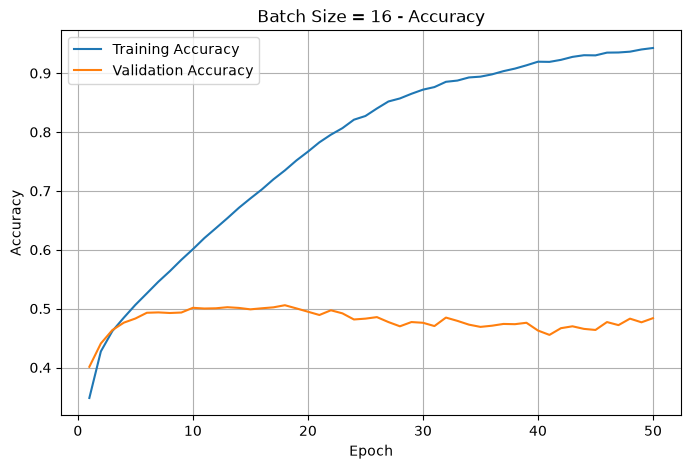

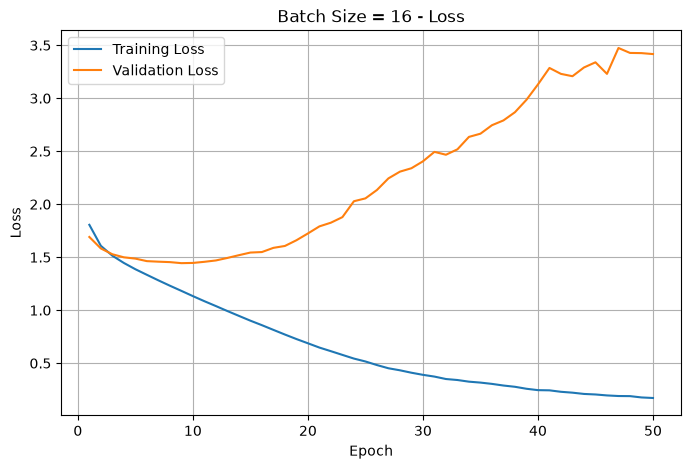

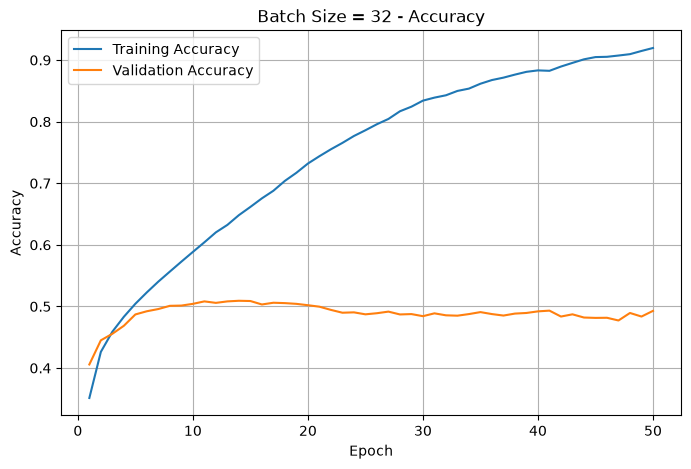

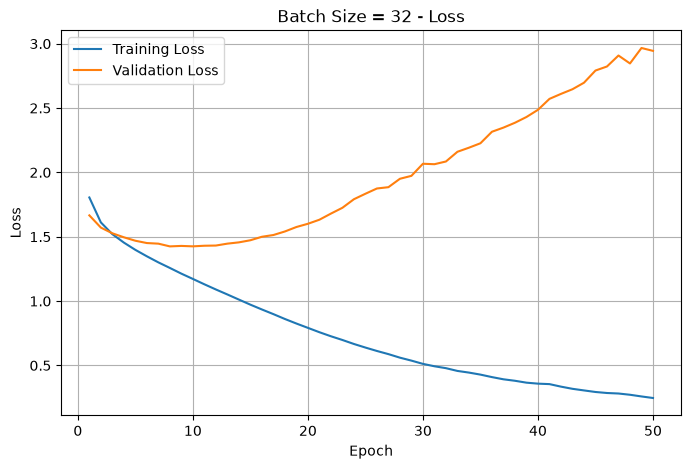

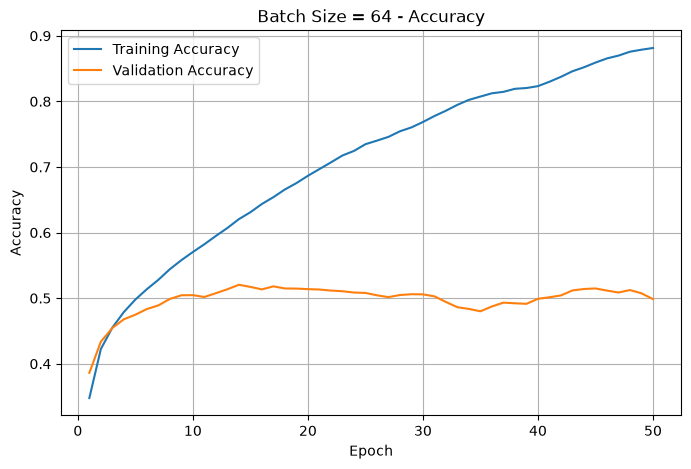

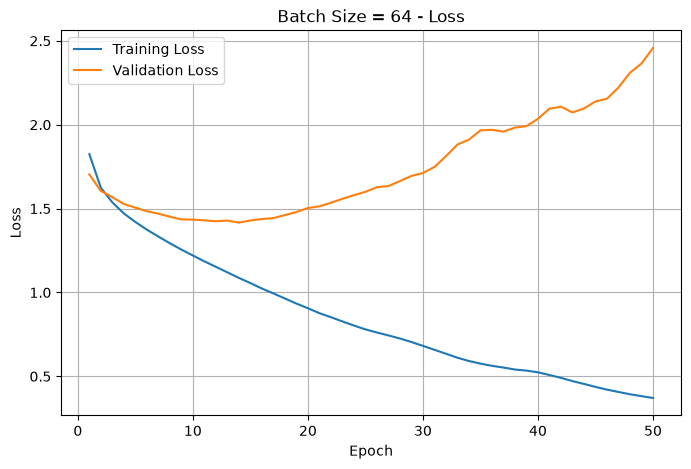

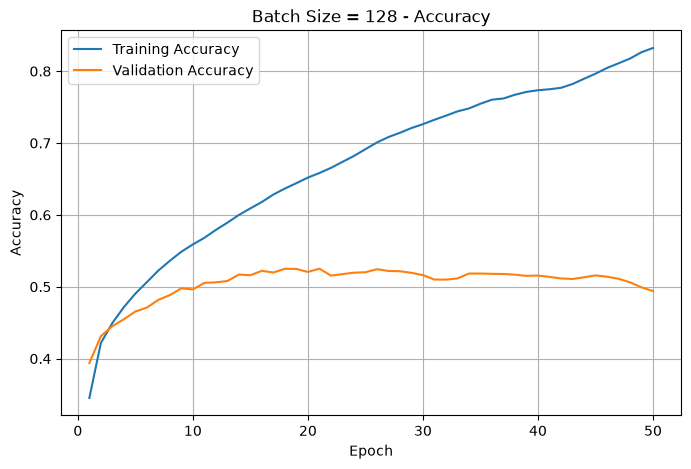

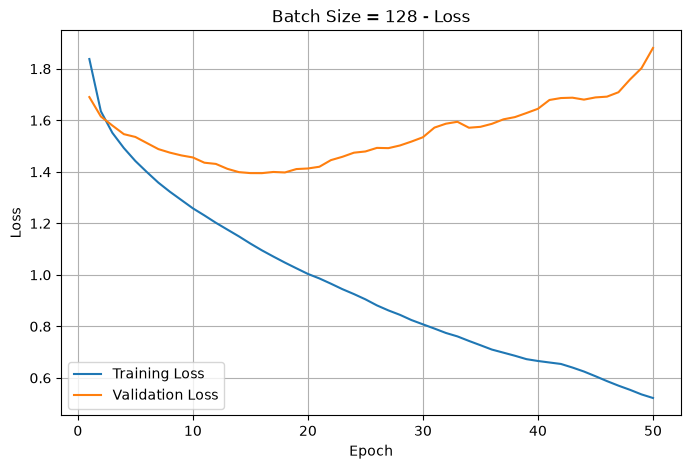

In [88]:
for batch_size, history in batch_size_histories.items():

    epochs_range = range(1, len(history["accuracy"]) + 1)

    # Accuracy
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Batch Size = {batch_size} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Batch Size = {batch_size} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

1. Which Batch Size produced the best result?

Batch Size 128 produced the best overall result. It achieved the highest validation accuracy (52.52%) and the lowest minimum validation loss (1.3948) among the tested batch sizes.

2. Did increasing Batch Size automatically improve the model?

Not automatically, but in this experiment the trend was consistent: 16 reached 50.58%, 32 reached 50.92%, 64 reached 52.04% and 128 reached 52.52%. Validation accuracy improved at every step and minimum validation loss fell at every step, so within the range tested the larger batch was always the better choice. The gain from 64 to 128 was only 0.48 points, however, which is inside the noise of a 5,000-image validation set, so the advantage over 64 is not clearly established.

3. What effect did Batch Size have on the learning curves?

The clearest effect was on overfitting. Smaller batches perform more weight updates per epoch and drove training accuracy much higher within the fixed 50 epochs, reaching 94.27% at batch 16 against 83.22% at batch 128, while validation accuracy moved in the opposite direction. The smaller batches also diverged much harder: final validation loss was 3.4169 at batch 16 against 1.8806 at batch 128, and they reached their minimum validation loss as early as epoch 9, compared with epoch 16 for batch 128. Larger batches therefore trained more slowly but generalized better here.


### Optimizer Experiment

In [89]:
# Part 11 - Optimizer Experiment
OPTIMIZERS = {
    "Adam": 0.0001,
    "SGD": 0.01
}

BEST_BATCH_SIZE = 128

optimizer_results = {}
optimizer_histories = {}

print("Optimizers:", OPTIMIZERS)
print("Batch size:", BEST_BATCH_SIZE)
print("Architecture:", [512, 512, 512])
print("Epochs:", EPOCHS)

Optimizers: {'Adam': 0.0001, 'SGD': 0.01}
Batch size: 128
Architecture: [512, 512, 512]
Epochs: 50


In [90]:
def build_optimizer_model(optimizer_name, learning_rate):

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    if optimizer_name == "Adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":

        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [91]:
for optimizer_name, learning_rate in OPTIMIZERS.items():

    print("\n" + "=" * 60)
    print(f"Training with Optimizer = {optimizer_name}")
    print(f"Learning Rate = {learning_rate}")
    print("=" * 60)

    # Fresh model with fresh weights
    model = build_optimizer_model(
        optimizer_name,
        learning_rate
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BEST_BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    optimizer_histories[optimizer_name] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    optimizer_results[optimizer_name] = {
        "Learning Rate": learning_rate,
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": final_train_acc,
        "Final Val Accuracy": final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Val Loss": final_val_loss
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
    print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"Final Training Loss      : {final_train_loss:.4f}")
    print(f"Final Validation Loss    : {final_val_loss:.4f}")


Training with Optimizer = Adam
Learning Rate = 0.0001


/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787477719.309189   37488 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4961765__.14


351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3428 - loss: 1.8458

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3430 - loss: 1.8455 - val_accuracy: 0.3960 - val_loss: 1.7050
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4197 - loss: 1.6410 - val_accuracy: 0.4300 - val_loss: 1.6235
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4502 - loss: 1.5546 - val_accuracy: 0.4510 - val_loss: 1.5638
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4715 - loss: 1.4931 - val_accuracy: 0.4630 - val_loss: 1.5300
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4903 - loss: 1.4436 - val_accuracy: 0.4676 - val_loss: 1.5098
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5067 - loss: 1.4004 - val_accuracy: 0.4794 - val_loss: 1.4886
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5210 - loss: 1.3609 - val_accuracy: 0.4904 - val_loss: 1.4617
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5334 - loss: 1.3247 - val_accuracy: 0.5002 - val_

I0000 00:00:1787477767.507599   37489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5042259__.14


334/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2768 - loss: 2.0266

I0000 00:00:1787477769.252856   37489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5042259__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2786 - loss: 2.0200 - val_accuracy: 0.3294 - val_loss: 1.8850
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3545 - loss: 1.8289 - val_accuracy: 0.3674 - val_loss: 1.7963
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3809 - loss: 1.7562 - val_accuracy: 0.3778 - val_loss: 1.7534
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3985 - loss: 1.7049 - val_accuracy: 0.3820 - val_loss: 1.7295
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4137 - loss: 1.6631 - val_accuracy: 0.3900 - val_loss: 1.7141
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4268 - loss: 1.6279 - val_accuracy: 0.3920 - val_loss: 1.7017
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4364 - loss: 1.5972 - val_accuracy: 0.3984 - val_loss: 1.6882
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4462 - loss: 1.5705 - val_accuracy: 0.4074 - val_

In [92]:
optimizer_df = pd.DataFrame(optimizer_results).T
optimizer_df

,Learning Rate,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
Adam,0.0001,0.5278,31.0,1.393220,14.0,0.815178,0.5254,0.555255,1.726494
SGD,0.0100,0.4928,50.0,1.480713,34.0,0.649156,0.4928,1.017327,1.499750


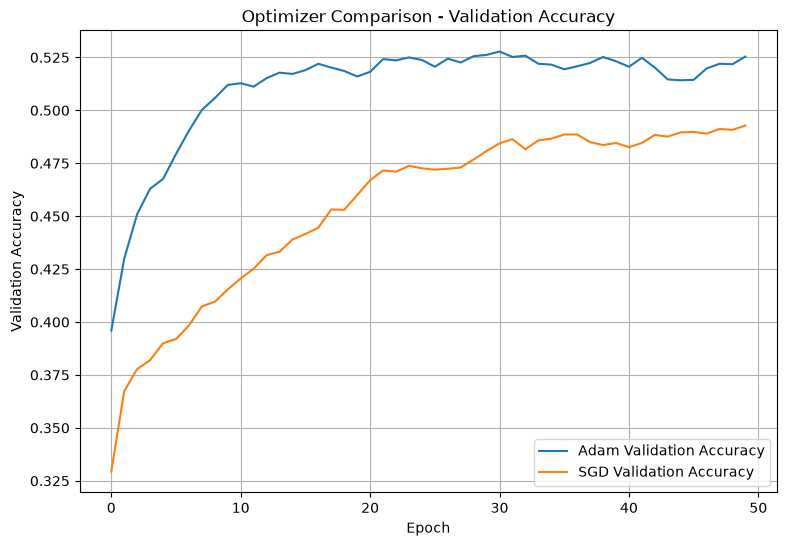

In [93]:
plt.figure(figsize=(9, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["val_accuracy"],
        label=f"{optimizer_name} Validation Accuracy"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison - Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

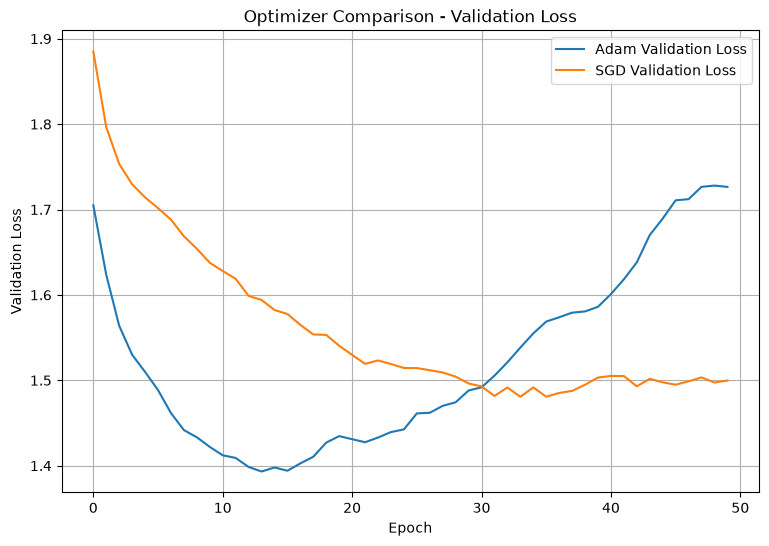

In [94]:
plt.figure(figsize=(9, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["val_loss"],
        label=f"{optimizer_name} Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison - Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Adam and SGD were compared using the same model architecture, batch size, training data, and 50 training epochs. Adam used a learning rate of 0.0001, while SGD used 0.01.

Adam achieved a higher best validation accuracy of 52.78%, compared with 49.28% for SGD. It also achieved a lower minimum validation loss of 1.3932, compared with 1.4807 for SGD, and reached its best validation accuracy at epoch 31, while SGD was still improving and reached its best only at epoch 50. Adam therefore converged considerably sooner.

SGD did finish with the lower final validation loss (1.4998 against 1.7265). This is because Adam kept fitting the training data after its best epoch, ending at 81.52% training accuracy against 64.92% for SGD, so the difference reflects how far each optimizer overfitted by epoch 50 rather than the quality of the best model each one reached. Therefore, Adam was selected as the preferred optimizer for this experiment because it provided the highest validation accuracy, the lowest minimum validation loss, and faster convergence, with Early Stopping available to recover its best epoch.


### Regularization Experiments

In [95]:
# Part 12 - Regularization Experiments
# Experiment A - Baseline
# No additional regularization

def build_baseline_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_model()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787477815.063801   37489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5123649__.14


335/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3389 - loss: 1.8590

I0000 00:00:1787477816.991237   37489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5123649__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3419 - loss: 1.8512 - val_accuracy: 0.3910 - val_loss: 1.7061
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4180 - loss: 1.6441 - val_accuracy: 0.4276 - val_loss: 1.6188
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4484 - loss: 1.5583 - val_accuracy: 0.4452 - val_loss: 1.5746
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4713 - loss: 1.4951 - val_accuracy: 0.4542 - val_loss: 1.5413
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4909 - loss: 1.4446 - val_accuracy: 0.4654 - val_loss: 1.5195
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5062 - loss: 1.4005 - val_accuracy: 0.4696 - val_loss: 1.4973
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5212 - loss: 1.3601 - val_accuracy: 0.4782 - val_loss: 1.4816
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5336 - loss: 1.3244 - val_accuracy: 0.4890 - val

In [96]:
# Experiment B - Dropout
# Dropout rate = 0.3

def build_dropout_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


dropout_model = build_dropout_model()

dropout_history = dropout_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787477864.310118   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5205329__.17


333/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2452 - loss: 2.0506

I0000 00:00:1787477866.932556   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5205329__.17


352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2487 - loss: 2.0421 - val_accuracy: 0.3532 - val_loss: 1.8285
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3322 - loss: 1.8502 - val_accuracy: 0.3780 - val_loss: 1.7345
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3638 - loss: 1.7681 - val_accuracy: 0.4178 - val_loss: 1.6587
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3862 - loss: 1.7137 - val_accuracy: 0.4226 - val_loss: 1.6356
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4012 - loss: 1.6752 - val_accuracy: 0.4468 - val_loss: 1.5899
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4156 - loss: 1.6387 - val_accuracy: 0.4466 - val_loss: 1.5703
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4270 - loss: 1.6112 - val_accuracy: 0.4632 - val_loss: 1.5483
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4344 - loss: 1.5836 - val_accuracy: 0.4706 - val

In [97]:
# Experiment C - Early Stopping

def build_early_stopping_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


early_stopping_model = build_early_stopping_model()

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_stopping_history = early_stopping_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50


I0000 00:00:1787477915.476931   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5286757__.14


340/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3423 - loss: 1.8524

I0000 00:00:1787477917.325883   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5286757__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3436 - loss: 1.8481 - val_accuracy: 0.4054 - val_loss: 1.7018
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4168 - loss: 1.6479 - val_accuracy: 0.4284 - val_loss: 1.6164
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4461 - loss: 1.5631 - val_accuracy: 0.4554 - val_loss: 1.5549
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4710 - loss: 1.5005 - val_accuracy: 0.4658 - val_loss: 1.5250
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4917 - loss: 1.4485 - val_accuracy: 0.4756 - val_loss: 1.4950
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5073 - loss: 1.4047 - val_accuracy: 0.4862 - val_loss: 1.4709
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5212 - loss: 1.3639 - val_accuracy: 0.4916 - val_loss: 1.4508
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5331 - loss: 1.3282 - val_accuracy: 0.4978 - val_

In [98]:
# Experiment D - L2 Regularization

def build_l2_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


l2_model = build_l2_model()

l2_history = l2_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787477935.595641   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5316085__.18


344/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3417 - loss: 2.0183

I0000 00:00:1787477937.507339   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5316085__.18


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3425 - loss: 2.0153 - val_accuracy: 0.3972 - val_loss: 1.8618
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4183 - loss: 1.7980 - val_accuracy: 0.4208 - val_loss: 1.7725
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4464 - loss: 1.7086 - val_accuracy: 0.4484 - val_loss: 1.7212
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4692 - loss: 1.6447 - val_accuracy: 0.4574 - val_loss: 1.6896
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4893 - loss: 1.5913 - val_accuracy: 0.4652 - val_loss: 1.6668
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5044 - loss: 1.5477 - val_accuracy: 0.4712 - val_loss: 1.6507
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5194 - loss: 1.5079 - val_accuracy: 0.4826 - val_loss: 1.6302
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5306 - loss: 1.4730 - val_accuracy: 0.4874 - val

In [99]:
# Part 12 - Compare Results

experiments = {
    "Baseline": baseline_history,
    "Dropout": dropout_history,
    "Early Stopping": early_stopping_history,
    "L2": l2_history
}

for name, history in experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Val Accuracy:   {val_acc:.4f}")
    print(f"Generalization Gap:   {gap:.4f}")
    print(f"Final Train Loss:     {train_loss:.4f}")
    print(f"Final Val Loss:       {val_loss:.4f}")


Baseline
Final Train Accuracy: 0.8199
Final Val Accuracy:   0.4988
Generalization Gap:   0.3211
Final Train Loss:     0.5326
Final Val Loss:       1.8616

Dropout
Final Train Accuracy: 0.5863
Final Val Accuracy:   0.5416
Generalization Gap:   0.0447
Final Train Loss:     1.1483
Final Val Loss:       1.3022

Early Stopping
Final Train Accuracy: 0.6259
Final Val Accuracy:   0.5172
Generalization Gap:   0.1087
Final Train Loss:     1.0820
Final Val Loss:       1.4264

L2
Final Train Accuracy: 0.7983
Final Val Accuracy:   0.5230
Generalization Gap:   0.2753
Final Train Loss:     0.7677
Final Val Loss:       1.8350


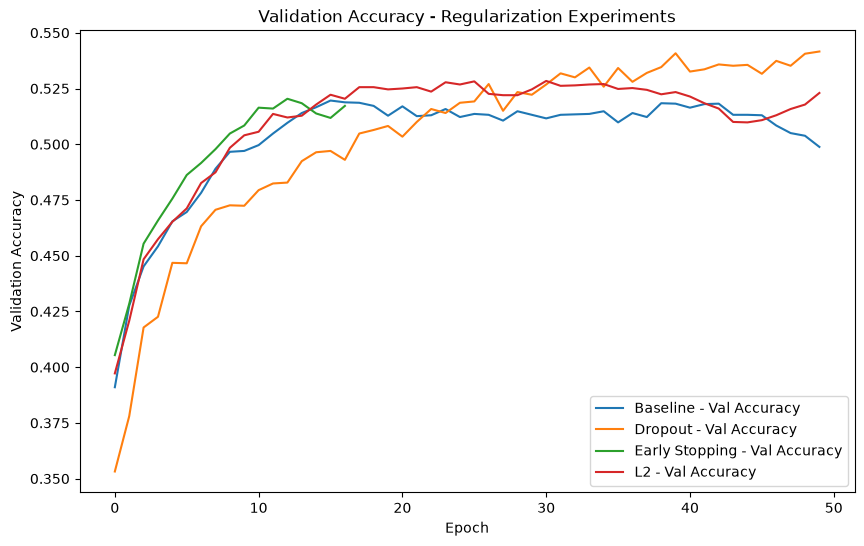

In [100]:
import matplotlib.pyplot as plt

# Accuracy curves
plt.figure(figsize=(10, 6))

for name, history in experiments.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"{name} - Val Accuracy"
    )

plt.title("Validation Accuracy - Regularization Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

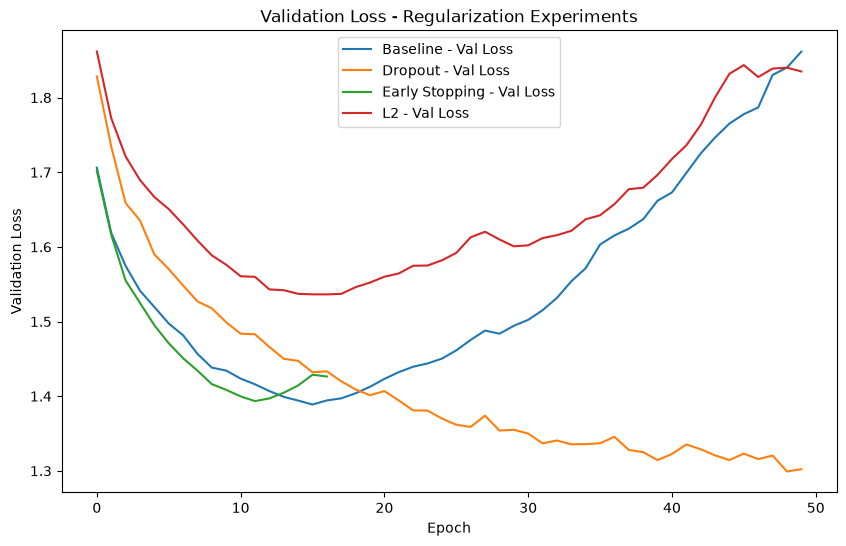

In [101]:
# Loss curves
plt.figure(figsize=(10, 6))

for name, history in experiments.items():
    plt.plot(
        history.history["val_loss"],
        label=f"{name} - Val Loss"
    )

plt.title("Validation Loss - Regularization Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [102]:
# Part 12 - Compare Results

experiments = {
    "Baseline": baseline_history,
    "Dropout": dropout_history,
    "Early Stopping": early_stopping_history,
    "L2": l2_history
}

for name, history in experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    # Generalization gap
    gap = train_acc - val_acc

    # Best validation performance
    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(f"Final Train Accuracy:      {train_acc:.4f}")
    print(f"Final Val Accuracy:        {val_acc:.4f}")
    print(f"Generalization Gap:        {gap:.4f}")
    print(f"Final Train Loss:          {train_loss:.4f}")
    print(f"Final Val Loss:            {val_loss:.4f}")
    print(f"Best Val Accuracy:         {best_val_acc:.4f}")
    print(f"Minimum Val Loss:          {min_val_loss:.4f}")


Baseline
Final Train Accuracy:      0.8199
Final Val Accuracy:        0.4988
Generalization Gap:        0.3211
Final Train Loss:          0.5326
Final Val Loss:            1.8616
Best Val Accuracy:         0.5196
Minimum Val Loss:          1.3889

Dropout
Final Train Accuracy:      0.5863
Final Val Accuracy:        0.5416
Generalization Gap:        0.0447
Final Train Loss:          1.1483
Final Val Loss:            1.3022
Best Val Accuracy:         0.5416
Minimum Val Loss:          1.2991

Early Stopping
Final Train Accuracy:      0.6259
Final Val Accuracy:        0.5172
Generalization Gap:        0.1087
Final Train Loss:          1.0820
Final Val Loss:            1.4264
Best Val Accuracy:         0.5204
Minimum Val Loss:          1.3934

L2
Final Train Accuracy:      0.7983
Final Val Accuracy:        0.5230
Generalization Gap:        0.2753
Final Train Loss:          0.7677
Final Val Loss:            1.8350
Best Val Accuracy:         0.5284
Minimum Val Loss:          1.5364


Dropout produced the best result among the regularization experiments. It achieved the highest validation accuracy of 54.16%, improving over the baseline accuracy of 49.88%, and it reduced the generalization gap from 32.11% to 4.47%. It also reached the lowest final validation loss of 1.3022, compared with 1.8616 for the baseline. Early Stopping was second, reaching 51.72% validation accuracy with a gap of 10.87%. L2 Regularization reached 52.30%, but left the gap almost unchanged at 27.53%. The baseline without regularization showed the clearest overfitting, ending at 81.99% training accuracy against 49.88% validation accuracy. Therefore, Dropout provided the best overall balance between validation performance and generalization in this experiment.


### PART 13

In [103]:
# Part 13 - Training Stability Experiment
# Experiment A - Without Batch Normalization

def build_no_batchnorm_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


no_bn_model = build_no_batchnorm_model()

no_bn_history = no_bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787477985.825466   37488 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5397543__.14


350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3410 - loss: 1.8441

I0000 00:00:1787477987.639118   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5397543__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3412 - loss: 1.8432 - val_accuracy: 0.3932 - val_loss: 1.7030
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4183 - loss: 1.6442 - val_accuracy: 0.4334 - val_loss: 1.6124
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4492 - loss: 1.5580 - val_accuracy: 0.4482 - val_loss: 1.5654
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4719 - loss: 1.4955 - val_accuracy: 0.4588 - val_loss: 1.5312
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4902 - loss: 1.4453 - val_accuracy: 0.4714 - val_loss: 1.5015
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5051 - loss: 1.4019 - val_accuracy: 0.4814 - val_loss: 1.4770
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5203 - loss: 1.3635 - val_accuracy: 0.4920 - val_loss: 1.4607
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5330 - loss: 1.3275 - val_accuracy: 0.4968 - val

In [104]:
# Experiment B - With Batch Normalization

def build_batchnorm_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


batchnorm_model = build_batchnorm_model()

batchnorm_history = batchnorm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787478036.932386   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5480285__.32


330/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4080 - loss: 1.6808

I0000 00:00:1787478039.063156   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5480285__.32


352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4117 - loss: 1.6692 - val_accuracy: 0.3734 - val_loss: 1.7650
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5241 - loss: 1.3537 - val_accuracy: 0.3718 - val_loss: 1.8170
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5879 - loss: 1.1880 - val_accuracy: 0.3984 - val_loss: 1.7480
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6421 - loss: 1.0540 - val_accuracy: 0.4232 - val_loss: 1.6881
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6927 - loss: 0.9327 - val_accuracy: 0.4172 - val_loss: 1.7476
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7376 - loss: 0.8200 - val_accuracy: 0.4160 - val_loss: 1.8311
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7827 - loss: 0.7125 - val_accuracy: 0.4096 - val_loss: 1.8858
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8232 - loss: 0.6122 - val_accuracy: 0.4114 - val

In [105]:
# Part 13 - Compare Results

experiments_bn = {
    "Without Batch Normalization": no_bn_history,
    "With Batch Normalization": batchnorm_history
}

for name, history in experiments_bn.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Val Accuracy:   {val_acc:.4f}")
    print(f"Generalization Gap:   {gap:.4f}")
    print(f"Final Train Loss:     {train_loss:.4f}")
    print(f"Final Val Loss:       {val_loss:.4f}")
    print(f"Best Val Accuracy:    {best_val_acc:.4f}")
    print(f"Minimum Val Loss:     {min_val_loss:.4f}")


Without Batch Normalization
Final Train Accuracy: 0.8100
Final Val Accuracy:   0.5138
Generalization Gap:   0.2962
Final Train Loss:     0.5605
Final Val Loss:       1.8096
Best Val Accuracy:    0.5318
Minimum Val Loss:     1.3930

With Batch Normalization
Final Train Accuracy: 0.9920
Final Val Accuracy:   0.4070
Generalization Gap:   0.5850
Final Train Loss:     0.0316
Final Val Loss:       4.4448
Best Val Accuracy:    0.4464
Minimum Val Loss:     1.6881


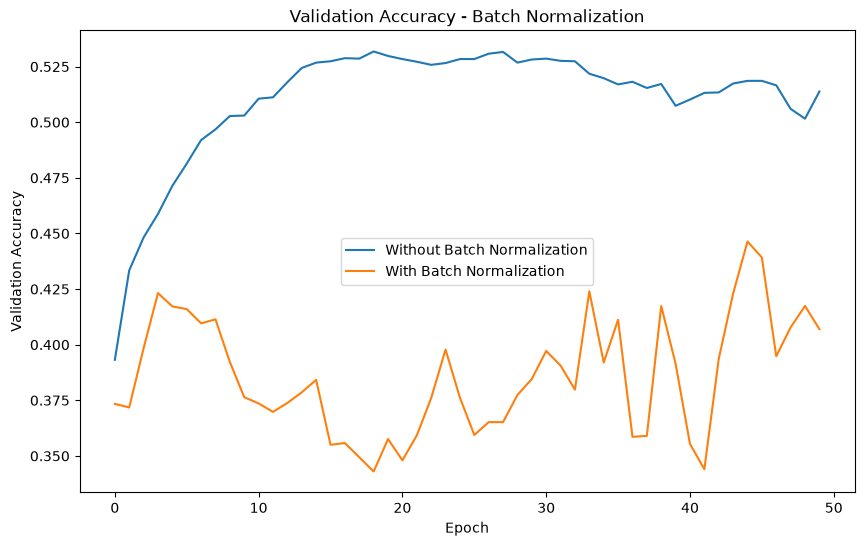

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    no_bn_history.history["val_accuracy"],
    label="Without Batch Normalization"
)

plt.plot(
    batchnorm_history.history["val_accuracy"],
    label="With Batch Normalization"
)

plt.title("Validation Accuracy - Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

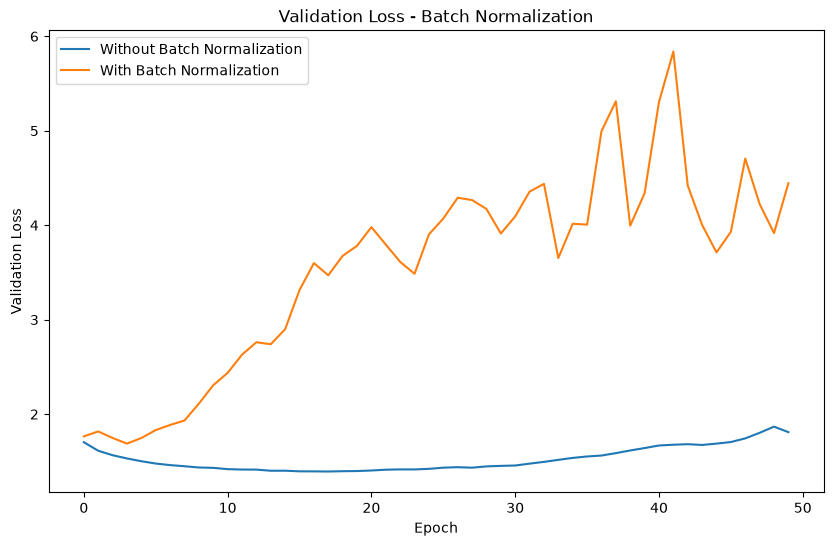

In [107]:
plt.figure(figsize=(10, 6))

plt.plot(
    no_bn_history.history["val_loss"],
    label="Without Batch Normalization"
)

plt.plot(
    batchnorm_history.history["val_loss"],
    label="With Batch Normalization"
)

plt.title("Validation Loss - Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

### Part 13 - Training Stability Experiment

Batch Normalization was evaluated using the same three-hidden-layer architecture, optimizer, learning rate, batch size, and number of epochs. The only difference was the addition of Batch Normalization after the Dense layers.

The model without Batch Normalization achieved a final training accuracy of **81.00%** and a validation accuracy of **51.38%**, with a generalization gap of **29.62%**. Its minimum validation loss was **1.3930**.

With Batch Normalization, the training accuracy increased substantially to **99.20%**, but the validation accuracy decreased to **40.70%**. The generalization gap increased to **58.50%**, and the final validation loss reached **4.4448**. The best validation accuracy with Batch Normalization was only **44.64%**, compared with **53.18%** without it.

Therefore, Batch Normalization did not improve validation performance in this experiment. Instead, the large difference between training and validation performance indicates severe overfitting. Although Batch Normalization is designed to stabilize intermediate activations and can make deeper networks easier to train, its effect in this particular network did not lead to better generalization.

Based on these results, the model **without Batch Normalization** performed better on unseen validation data.



### Part 14

In [108]:
# Part 14 - Ablation Experiment
# Model A: With Dropout

# Dropout is the technique carried into the final model, so it is the one worth
# isolating. Part 12 ranked it first of the four regularizers; this experiment
# removes it and changes nothing else, to confirm that the ranking was Dropout
# and not some other difference in that run.
#
# set_seed is called inside each builder so both models start from identical
# initial weights. Without it the two runs differ by their initialisation as
# well as by Dropout, and the ablation is not controlled.

def build_model_with_dropout():

    set_seed(SEED)

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_with_dropout = build_model_with_dropout()

history_with_dropout = model_with_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)


Epoch 1/50


I0000 00:00:1787478090.989044   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5562085__.17


343/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2474 - loss: 2.0483

I0000 00:00:1787478093.364881   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5562085__.17


352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2482 - loss: 2.0454 - val_accuracy: 0.3546 - val_loss: 1.8318
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3315 - loss: 1.8520 - val_accuracy: 0.3790 - val_loss: 1.7355
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3638 - loss: 1.7704 - val_accuracy: 0.4008 - val_loss: 1.6784
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3834 - loss: 1.7189 - val_accuracy: 0.4184 - val_loss: 1.6418
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4026 - loss: 1.6760 - val_accuracy: 0.4430 - val_loss: 1.5952
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4158 - loss: 1.6412 - val_accuracy: 0.4436 - val_loss: 1.5731
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4276 - loss: 1.6065 - val_accuracy: 0.4586 - val_loss: 1.5444
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4363 - loss: 1.5849 - val_accuracy: 0.4604 - val

In [109]:
# Model B: Without Dropout

def build_model_without_dropout():

    set_seed(SEED)

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_without_dropout = build_model_without_dropout()

history_without_dropout = model_without_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)


Epoch 1/50


I0000 00:00:1787478141.886289   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5643513__.14


349/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3426 - loss: 1.8454

I0000 00:00:1787478143.746213   37489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5643513__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3431 - loss: 1.8441 - val_accuracy: 0.3994 - val_loss: 1.6931
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4189 - loss: 1.6380 - val_accuracy: 0.4308 - val_loss: 1.6060
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4483 - loss: 1.5546 - val_accuracy: 0.4490 - val_loss: 1.5562
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4717 - loss: 1.4927 - val_accuracy: 0.4608 - val_loss: 1.5209
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4905 - loss: 1.4425 - val_accuracy: 0.4756 - val_loss: 1.4958
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5062 - loss: 1.3996 - val_accuracy: 0.4834 - val_loss: 1.4762
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5191 - loss: 1.3611 - val_accuracy: 0.4868 - val_loss: 1.4606
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5339 - loss: 1.3257 - val_accuracy: 0.4906 - val

In [110]:
# Part 14 - Ablation Comparison

ablation_experiments = {
    "With Dropout": history_with_dropout,
    "Without Dropout": history_without_dropout
}

for name, history in ablation_experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(f"Final Train Accuracy:   {train_acc:.4f}")
    print(f"Final Val Accuracy:     {val_acc:.4f}")
    print(f"Generalization Gap:     {gap:.4f}")
    print(f"Final Train Loss:       {train_loss:.4f}")
    print(f"Final Val Loss:         {val_loss:.4f}")
    print(f"Best Val Accuracy:      {best_val_acc:.4f}")
    print(f"Minimum Val Loss:       {min_val_loss:.4f}")



With Dropout
Final Train Accuracy:   0.5914
Final Val Accuracy:     0.5440
Generalization Gap:     0.0474
Final Train Loss:       1.1431
Final Val Loss:         1.3026
Best Val Accuracy:      0.5462
Minimum Val Loss:       1.2971

Without Dropout
Final Train Accuracy:   0.8180
Final Val Accuracy:     0.5104
Generalization Gap:     0.3076
Final Train Loss:       0.5412
Final Val Loss:         1.8046
Best Val Accuracy:      0.5284
Minimum Val Loss:       1.3955


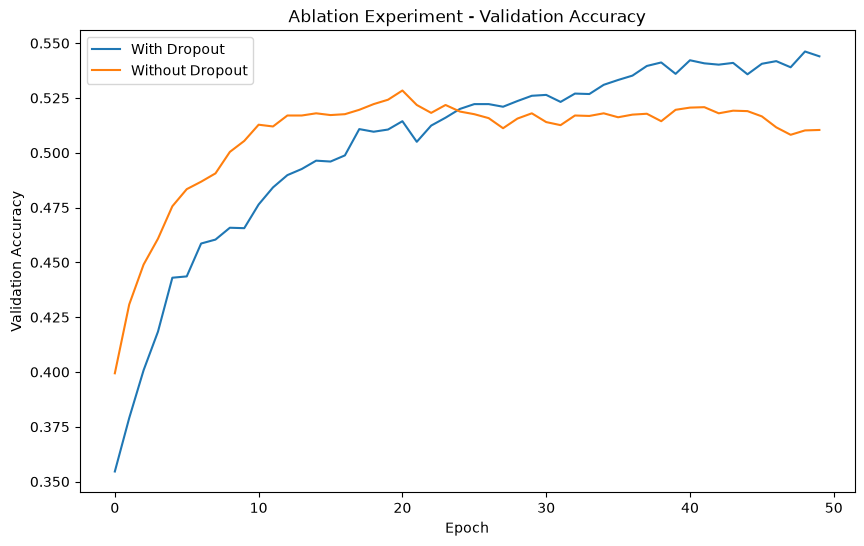

In [111]:
# Validation Accuracy Comparison

plt.figure(figsize=(10, 6))

plt.plot(
    history_with_dropout.history["val_accuracy"],
    label="With Dropout"
)

plt.plot(
    history_without_dropout.history["val_accuracy"],
    label="Without Dropout"
)

plt.title("Ablation Experiment - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


An ablation experiment was conducted to isolate the effect of Dropout. Two models were trained using the same architecture, optimizer, learning rate, batch size, and number of epochs, each reseeded before it was built so that both started from identical initial weights. The only difference was the presence or absence of Dropout.

The model with Dropout achieved a higher final validation accuracy of 54.40%, compared with 51.04% without Dropout. It also reduced the generalization gap from 30.76% to 4.74%, indicating a substantial improvement in generalization.

The two models were also clearly separated on their best validation accuracy, 54.62% with Dropout against 52.84% without it, a difference of 89 images out of 5,000. The model with Dropout additionally reached the lower minimum validation loss (1.2971 compared with 1.3955).

Therefore, Dropout improved the peak validation performance and the final-epoch metrics at the same time, and it was the most effective single regularizer tested. This is the evidence that carries Dropout into the final model in Part 15.


### Part15

In [112]:
# Part 15 - Build Your Final Model
# Final Optimized Neural Network

# Dropout, not L2, on the evidence of Parts 12 and 14: Dropout ranked first of
# the four regularizers in Part 12, and the Part 14 ablation isolates its
# effect. L2 is excluded because it changed almost nothing when isolated, and
# Batch Normalization because Part 13 showed it lowering validation accuracy.

def build_final_model():

    set_seed(SEED)

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build final model
final_model = build_final_model()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train final model
final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

# Model summary
final_model.summary()

# Number of trainable parameters
trainable_params = sum(
    layer.count_params()
    for layer in final_model.layers
    if layer.trainable
)

print("\nTrainable Parameters:", trainable_params)


Epoch 1/50


I0000 00:00:1787478192.765879   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5725193__.17


350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2480 - loss: 2.0461

I0000 00:00:1787478195.102430   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5725193__.17


352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2482 - loss: 2.0454 - val_accuracy: 0.3546 - val_loss: 1.8318
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3315 - loss: 1.8520 - val_accuracy: 0.3790 - val_loss: 1.7355
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3638 - loss: 1.7704 - val_accuracy: 0.4008 - val_loss: 1.6784
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3834 - loss: 1.7189 - val_accuracy: 0.4184 - val_loss: 1.6418
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4026 - loss: 1.6760 - val_accuracy: 0.4430 - val_loss: 1.5952
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4158 - loss: 1.6412 - val_accuracy: 0.4436 - val_loss: 1.5731
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4276 - loss: 1.6065 - val_accuracy: 0.4586 - val_loss: 1.5444
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4363 - loss: 1.5849 - val_accuracy: 0.4604 - val

...

 Total params: 6,311,456 (24.08 MB)

 Trainable params: 2,103,818 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,207,638 (16.05 MB)


Trainable Parameters: 2103818


The final optimized neural network uses three hidden Dense layers with 512 neurons each. Based on the previous experiments, Adam with a learning rate of 0.0001 and a batch size of 128 were selected. Dropout with a rate of 0.3 after each hidden layer was included because Part 12 ranked it first of the four regularizers, reaching 54.16% validation accuracy against 52.30% for L2 and 51.72% for Early Stopping, and because the Part 14 ablation isolated its effect and confirmed it, raising best validation accuracy from 52.84% to 54.62% and cutting the generalization gap from 30.76% to 4.74%. L2 regularization was excluded because it left the generalization gap almost unchanged when tested on its own in Part 12. Batch Normalization was excluded because it resulted in substantially lower validation performance in the Part 13 experiment. Early Stopping was included to monitor validation loss, prevent unnecessary training, and restore the best model weights.

The final model summary shows 2,103,818 trainable parameters, with 0 non-trainable parameters.


### Part16

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5408 - loss: 1.2815
FINAL TEST SET RESULTS
Test Loss     : 1.2815
Test Accuracy : 0.5408
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Confusion Matrix:
[[607  28  98  13  36  11  20  23 123  41]
 [ 35 662  18  17  12  10  13  17  68 148]
 [ 58  13 461  76 153  59  89  51  19  21]
 [ 31  18 111 347  68 166 143  49  23  44]
 [ 45   8 168  58 499  31  94  62  25  10]
 [ 18   9 117 217  82 379  74  64  22  18]
 [  3  17  92  74 115  30 624  16  13  16]
 [ 35  14  71  72 101  65  21 571  13  37]
 [110  68  17  30  27   9   5  11 678  45]
 [ 36 182  16  26  15  10  18  49  68 580]]


<Figure size 1000x800 with 0 Axes>

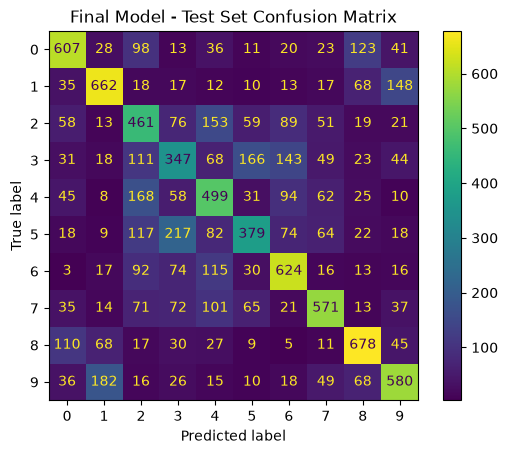


Overall Test Metrics:
Precision : 0.5421
Recall    : 0.5408
F1-score  : 0.5399

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.61      0.61      1000
           1       0.65      0.66      0.66      1000
           2       0.39      0.46      0.43      1000
           3       0.37      0.35      0.36      1000
           4       0.45      0.50      0.47      1000
           5       0.49      0.38      0.43      1000
           6       0.57      0.62      0.59      1000
           7       0.63      0.57      0.60      1000
           8       0.64      0.68      0.66      1000
           9       0.60      0.58      0.59      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000



In [113]:
#
# Part 16 - Final Test Evaluation
#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)


#
# 1. Evaluate Final Model on Test Set
#

test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


#
# 2. Generate Predictions
#

y_pred_prob = final_model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)


#
# 3. Confusion Matrix
#

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


#
# 4. Plot Confusion Matrix
#

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Final Model - Test Set Confusion Matrix")
plt.show()


#
# 5. Precision, Recall, F1-Score
#

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nOverall Test Metrics:")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


#
# 6. Detailed Classification Report
#

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

The final model achieved a test accuracy of 54.08%, with a weighted precision of 54.21%, recall of 54.08%, and F1-score of 53.99%. The classification report shows noticeable differences between classes. Class 8 achieved the highest recall at 68%, while Class 1 achieved the highest precision at 65%. Class 0 showed closely balanced precision and recall at 62% and 61%. In contrast, Class 3 had the weakest performance, with a recall of only 35% and an F1-score of 36%, indicating that the model struggled to correctly identify this class. Overall, the test results indicate that the final model provides moderate classification performance but still has difficulty distinguishing several classes.


In [114]:
# Part 17 - Error Analysis

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Classification report as dictionary
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Create per-class results table
class_results = []

for class_id in range(10):
    class_results.append({
        "Class": class_id,
        "Precision": report[str(class_id)]["precision"],
        "Recall": report[str(class_id)]["recall"],
        "F1-Score": report[str(class_id)]["f1-score"],
        "Support": report[str(class_id)]["support"]
    })

class_results_df = pd.DataFrame(class_results)

print("Per-Class Performance:")
display(class_results_df)

# Easiest classes based on F1-score
easiest_classes = class_results_df.sort_values(
    "F1-Score",
    ascending=False
)

print("\nEasiest Classes:")
display(easiest_classes)

# Most difficult classes
difficult_classes = class_results_df.sort_values(
    "F1-Score",
    ascending=True
)

print("\nMost Difficult Classes:")
display(difficult_classes)

Per-Class Performance:


,Class,Precision,Recall,F1-Score,Support
0,0,0.620654,0.607,0.613751,1000.0
1,1,0.649657,0.662,0.655770,1000.0
2,2,0.394354,0.461,0.425081,1000.0
3,3,0.373118,0.347,0.359585,1000.0
4,4,0.450361,0.499,0.473435,1000.0
5,5,0.492208,0.379,0.428249,1000.0
6,6,0.566757,0.624,0.594003,1000.0
7,7,0.625411,0.571,0.596968,1000.0
8,8,0.644487,0.678,0.660819,1000.0
9,9,0.604167,0.580,0.591837,1000.0



Easiest Classes:


,Class,Precision,Recall,F1-Score,Support
8,8,0.644487,0.678,0.660819,1000.0
1,1,0.649657,0.662,0.655770,1000.0
0,0,0.620654,0.607,0.613751,1000.0
7,7,0.625411,0.571,0.596968,1000.0
6,6,0.566757,0.624,0.594003,1000.0
9,9,0.604167,0.580,0.591837,1000.0
4,4,0.450361,0.499,0.473435,1000.0
5,5,0.492208,0.379,0.428249,1000.0
2,2,0.394354,0.461,0.425081,1000.0
3,3,0.373118,0.347,0.359585,1000.0



Most Difficult Classes:


,Class,Precision,Recall,F1-Score,Support
3,3,0.373118,0.347,0.359585,1000.0
2,2,0.394354,0.461,0.425081,1000.0
5,5,0.492208,0.379,0.428249,1000.0
4,4,0.450361,0.499,0.473435,1000.0
9,9,0.604167,0.580,0.591837,1000.0
6,6,0.566757,0.624,0.594003,1000.0
7,7,0.625411,0.571,0.596968,1000.0
0,0,0.620654,0.607,0.613751,1000.0
1,1,0.649657,0.662,0.655770,1000.0
8,8,0.644487,0.678,0.660819,1000.0


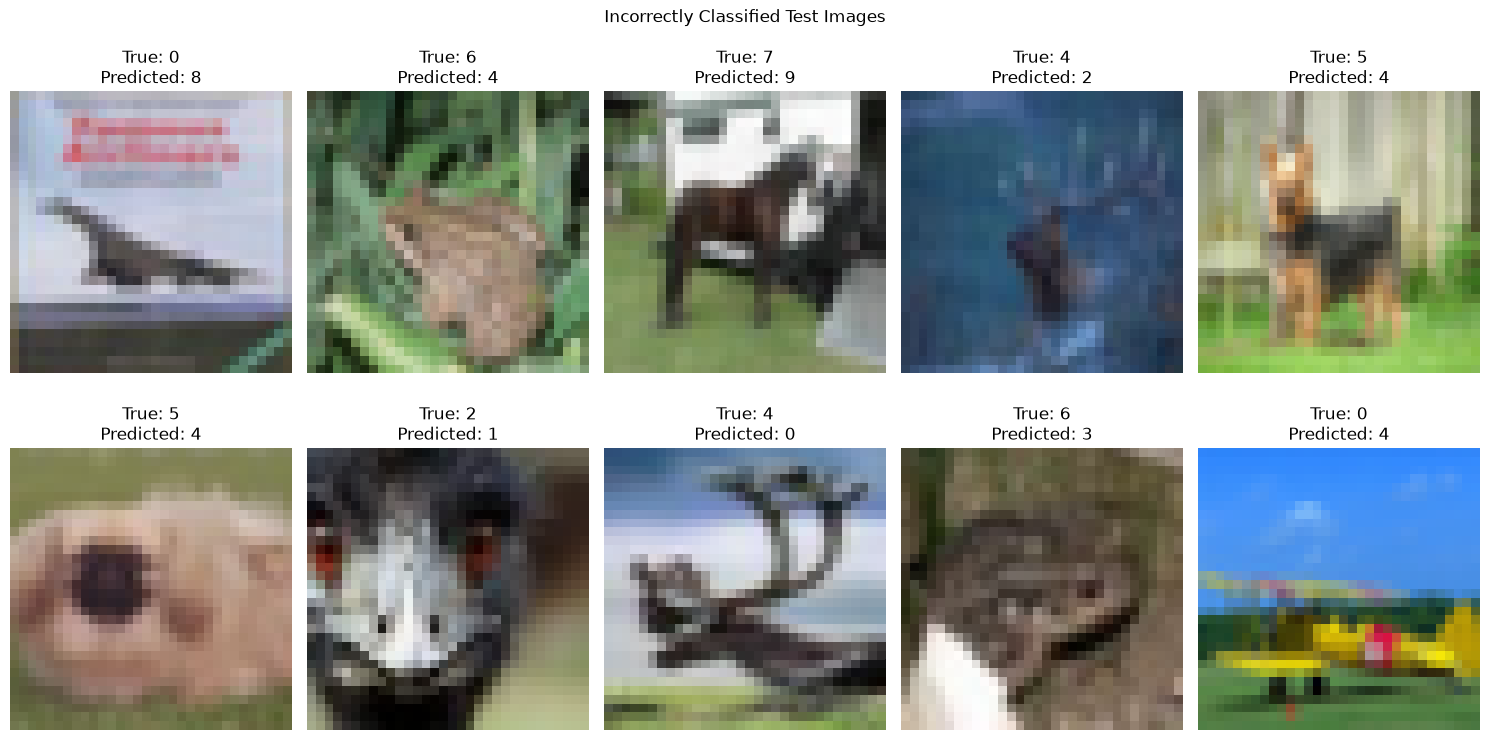

In [115]:
incorrect_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))

for i, idx in enumerate(incorrect_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: {y_test[idx]}\nPredicted: {y_pred[idx]}"
    )

    plt.axis("off")

plt.suptitle("Incorrectly Classified Test Images")
plt.tight_layout()
plt.show()

The easiest classes for the final model were Class 8 (ship) and Class 1 (automobile), with F1-scores of 66.08% and 65.58%, respectively. The most difficult classes were Class 3 (cat), Class 2 (bird), and Class 5 (dog), with F1-scores of 35.96%, 42.51%, and 42.82%.

The errors mainly occur between visually similar classes. The confusion matrix shows the clearest example: 166 cats were predicted as dogs and 217 dogs were predicted as cats, 383 errors in total and the largest confusion pair in the table, followed by automobile and truck at 330. Cats and dogs are difficult to distinguish because they may have similar shapes, poses, and colors. The low 32x32 image resolution also removes important visual details. In addition, the Dense Neural Network processes the image after flattening it into a one-dimensional vector, so it does not directly capture spatial relationships between neighboring pixels. This makes it more difficult to recognize local shapes and patterns.

Overall, the error analysis shows that the model performs better on some visually distinctive classes but struggles with classes that have similar visual characteristics.


### Extra Experiment - Data Augmentation

Every result so far has trained on the same fixed 45,000 images. Data
augmentation creates new training images on the fly by transforming the
existing ones, which gives the network more variety to learn from without
collecting more data.

Augmentation is applied with Keras preprocessing layers placed **before**
`Flatten`, so they operate on the `(32, 32, 3)` image while it still has its
spatial structure. These layers are active only during `fit` and become an
identity function during `evaluate` and `predict`, so validation and test
scores are always measured on unmodified images.

Two augmentation settings are compared against no augmentation at all:

| Setting | Transformations |
|---|---|
| No Augmentation | none (control) |
| Flip only | random horizontal flip |
| Flip + Shift | random horizontal flip, plus random shift of up to 10% (about 3 pixels) |

The split between the two is deliberate. A horizontally flipped car is still a
car, and to a Dense network the flipped image is an entirely different
3072-value vector, so the flip genuinely adds variety. A **shift** is different:
a Dense layer has one weight per pixel position, so moving an object three
pixels to the right changes almost every input value and the network has to
learn that object again from scratch. Convolutional networks handle shifts
naturally; Dense networks do not. Comparing these two settings measures exactly
that weakness.

All three runs use identical architecture, optimizer, learning rate, batch size,
epochs and seed, so augmentation is the only variable (the Part 5 fair
comparison rule).


In [116]:
# Extra Experiment - Data Augmentation

import numpy as np

# Held identical across all three runs so augmentation is the only variable.
AUG_HIDDEN_UNITS = [512, 512, 512]
AUG_LEARNING_RATE = 0.0001
AUG_BATCH_SIZE = 128
AUG_EPOCHS = 100

AUGMENTATIONS = {
    "No Augmentation": [],
    "Flip only": [
        layers.RandomFlip("horizontal", seed=SEED),
    ],
    "Flip + Shift": [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(0.1, 0.1, seed=SEED),
    ],
}


def build_augmented_model(augmentation_layers):
    set_seed(SEED)

    model = keras.Sequential(
        [keras.Input(shape=IMG_SHAPE)]
        + list(augmentation_layers)          # operate on the image, before Flatten
        + [layers.Flatten()]
        + [layers.Dense(u, activation="relu") for u in AUG_HIDDEN_UNITS]
        + [layers.Dense(NUM_CLASSES, activation="softmax")]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=AUG_LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    validate_model(model)   # confirms no forbidden layers and a 10-unit output
    return model


augmentation_histories = {}
augmentation_results = {}

for name, aug_layers in AUGMENTATIONS.items():
    print(f"training: {name} ...")

    model = build_augmented_model(aug_layers)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=AUG_EPOCHS,
        batch_size=AUG_BATCH_SIZE,
        verbose=0,
    ).history

    augmentation_histories[name] = history

    best_epoch = int(np.argmax(history["val_accuracy"])) + 1
    augmentation_results[name] = {
        "Best Val Acc.": round(max(history["val_accuracy"]), 4),
        "Best Val Acc Epoch": best_epoch,
        "Min Val Loss": round(min(history["val_loss"]), 4),
        "Final Train Acc.": round(history["accuracy"][-1], 4),
        "Gap": round(history["accuracy"][-1] - history["val_accuracy"][-1], 4),
    }

    r = augmentation_results[name]
    print(
        f"  best val acc {r['Best Val Acc.']:.4f} (epoch {r['Best Val Acc Epoch']})"
        f" | min val loss {r['Min Val Loss']:.4f}"
        f" | gap {r['Gap']:+.4f}"
    )

training: No Augmentation ...


I0000 00:00:1787478248.641124   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5811069__.14
I0000 00:00:1787478250.508188   37487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5811069__.14


  best val acc 0.5284 (epoch 21) | min val loss 1.3955 | gap +0.4085
training: Flip only ...


I0000 00:00:1787478341.494894   37494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5972177__.14
I0000 00:00:1787478343.527900   37490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5972177__.14


  best val acc 0.5492 (epoch 27) | min val loss 1.3141 | gap +0.3631
training: Flip + Shift ...
  best val acc 0.5912 (epoch 79) | min val loss 1.2057 | gap +0.0791


In [117]:
# Extra Experiment - Augmentation Results Summary

augmentation_df = pd.DataFrame(augmentation_results).T

control = augmentation_results["No Augmentation"]["Best Val Acc."]
augmentation_df["Change vs Control"] = [
    f"{(r['Best Val Acc.'] - control) * 100:+.2f} pts" for r in augmentation_results.values()
]
augmentation_df["Images Gained"] = [
    f"{round((r['Best Val Acc.'] - control) * len(y_val)):+d}" for r in augmentation_results.values()
]

augmentation_df

,Best Val Acc.,Best Val Acc Epoch,Min Val Loss,Final Train Acc.,Gap,Change vs Control,Images Gained
No Augmentation,0.5284,21.0,1.3955,0.9295,0.4085,+0.00 pts,+0
Flip only,0.5492,27.0,1.3141,0.8831,0.3631,+2.08 pts,+104
Flip + Shift,0.5912,79.0,1.2057,0.6693,0.0791,+6.28 pts,+314


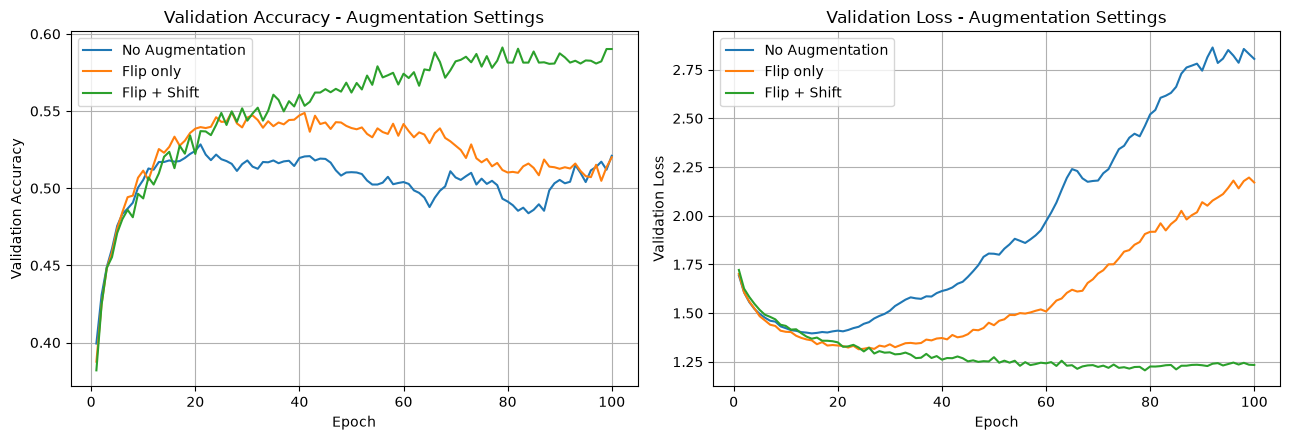

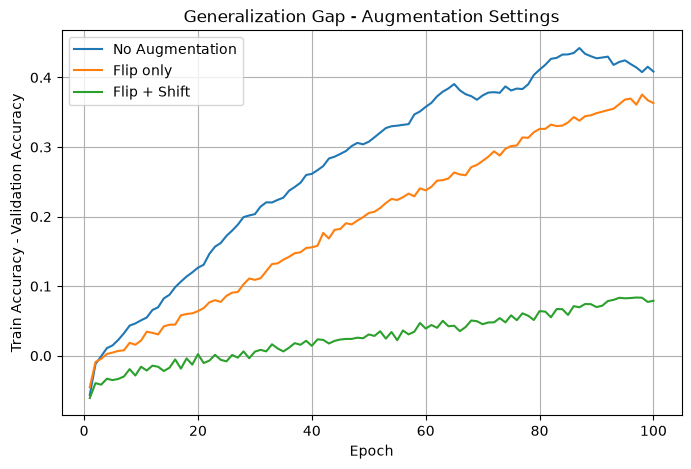

In [118]:
# Extra Experiment - Augmentation Learning Curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, history in augmentation_histories.items():
    epochs_range = range(1, len(history["accuracy"]) + 1)
    axes[0].plot(epochs_range, history["val_accuracy"], label=name)
    axes[1].plot(epochs_range, history["val_loss"], label=name)

axes[0].set_title("Validation Accuracy - Augmentation Settings")
axes[0].set_ylabel("Validation Accuracy")

axes[1].set_title("Validation Loss - Augmentation Settings")
axes[1].set_ylabel("Validation Loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

for name, history in augmentation_histories.items():
    gap = np.array(history["accuracy"]) - np.array(history["val_accuracy"])
    plt.plot(range(1, len(gap) + 1), gap, label=name)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.title("Generalization Gap - Augmentation Settings")
plt.legend()
plt.grid(True)
plt.show()


#### Augmentation experiment - answers

**1. Did augmentation improve validation accuracy?**

> Yes, and both settings cleared the threshold comfortably. Flip only reached
> **54.92%** best validation accuracy against the **52.84%** control, a gain of
> **2.08 points** (**+104 images**), which is about three standard errors.
> Flip + Shift reached **59.12%**, a gain of **6.28 points** (**+314 images**) —
> the highest validation accuracy recorded anywhere in this project, and far
> outside the noise band. Augmentation was the single most effective change
> tested, and it cost no additional parameters.

**2. Did augmentation reduce overfitting?**

> Yes, decisively, and that is where most of the benefit came from. The
> generalization gap fell from **0.4085** on the control to **0.3631** with flip
> and **0.0791** with flip + shift. Final training accuracy dropped from
> **92.95%** to **88.31%** to **66.93%** while validation accuracy rose at every
> step, which is exactly the signature of a network that can no longer memorise
> a fixed set of images. The control had stopped improving by epoch 21; the
> flip + shift run was still improving at epoch 79.

**3. Why did shifting behave differently from flipping?**

> The prediction was that shifting would hurt a Dense network, and the mechanism
> behind that prediction is real: a Dense layer holds one weight per pixel
> position, so a shifted image is a nearly unrelated 3072-value input and the
> network must learn the same object a second time. That cost is visible in how
> slowly the shifted run learned — it did not reach its best validation accuracy
> until epoch **79**, against epoch **27** for flip and epoch **21** for the
> control.
>
> What the experiment shows is that the cost was paid in training time rather
> than in final accuracy. The binding problem here was overfitting, not
> underfitting, and a shift is a far stronger defence against memorisation than
> a flip: it makes almost every epoch present genuinely new 3072-value vectors.
> Given a 100-epoch budget the network had room to absorb the harder task, and
> the anti-overfitting benefit outweighed the positional cost. A convolutional
> network would collect the same benefit without paying that cost at all,
> because it reuses the same filter at every position.

**4. What does this say about the limits of a Dense network on images?**

> Connects directly to Part 20: augmentation is one of the standard fixes for
> limited data in computer vision, and most of its benefit depends on the
> translation invariance that Dense layers do not have.


### part18

In [119]:
# Part 18 - Experiment Tracking

import json

import pandas as pd


def _history(h):
    """Accept either a Keras History object or a plain history dict."""
    return h.history if hasattr(h, "history") else h


def best_val(h):
    """Best validation accuracy reached during a run."""
    return max(_history(h)["val_accuracy"])


def saved_best(name):
    """Best validation accuracy from notebook 03-08, read from its saved results.

    The architecture comparison was run in the other notebook, so its scores are
    read from Results/ rather than restated here, where they could drift apart.
    """
    with open(ROOT / "Results" / f"{name}.json", encoding="utf-8") as f:
        return json.load(f)["best_val_accuracy"]


# Settings shared by every experiment that was not varying them.
ARCH, LR, BATCH, OPT = "Medium (3x512)", 0.0001, 128, "Adam"

# Each row reads its score from the run that produced it, so re-running any
# experiment and re-running this cell keeps the table correct automatically.
experiment_tracking = [
    {"Experiment": "Baseline", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(baseline_history)},

    {"Experiment": "Shallow", "Architecture": "Shallow (1x512)", "LR": "-", "Batch": "-",
     "Optimizer": "-", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": saved_best("shallow")},

    {"Experiment": "Medium", "Architecture": ARCH, "LR": "-", "Batch": "-",
     "Optimizer": "-", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": saved_best("medium")},

    {"Experiment": "Deep", "Architecture": "Deep (5x512)", "LR": "-", "Batch": "-",
     "Optimizer": "-", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": saved_best("deep")},

    {"Experiment": "LR Tuning", "Architecture": ARCH, "LR": BEST_LEARNING_RATE, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(learning_rate_histories[BEST_LEARNING_RATE])},

    {"Experiment": "Batch Tuning", "Architecture": ARCH, "LR": BEST_LEARNING_RATE, "Batch": BEST_BATCH_SIZE,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(batch_size_histories[BEST_BATCH_SIZE])},

    {"Experiment": "Optimizer (Adam)", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": "Adam", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(optimizer_histories["Adam"])},

    {"Experiment": "Optimizer (SGD)", "Architecture": ARCH, "LR": 0.01, "Batch": BATCH,
     "Optimizer": "SGD", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(optimizer_histories["SGD"])},

    {"Experiment": "Dropout", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": 0.3, "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(dropout_history)},

    {"Experiment": "Early Stopping", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "Yes", "Best Val Acc.": best_val(early_stopping_history)},

    {"Experiment": "L2", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": 0.0001,
     "Early Stop": "No", "Best Val Acc.": best_val(l2_history)},

    {"Experiment": "BatchNorm", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "Yes", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(batchnorm_history)},

    {"Experiment": "Final Model", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": 0.3, "BatchNorm": "No", "L2": "No",
     "Early Stop": "Yes", "Best Val Acc.": best_val(final_history)},
]

# Create DataFrame
experiment_df = pd.DataFrame(experiment_tracking)

# Convert accuracy to percentage
experiment_df["Best Val Acc."] = (
    experiment_df["Best Val Acc."] * 100
).round(2).astype(str) + "%"

# Display table
display(experiment_df)


,Experiment,Architecture,LR,Batch,Optimizer,Dropout,BatchNorm,L2,Early Stop,Best Val Acc.
0,Baseline,Medium (3x512),0.0001,128,Adam,No,No,No,No,51.96%
1,Shallow,Shallow (1x512),-,-,-,No,No,No,No,52.22%
2,Medium,Medium (3x512),-,-,-,No,No,No,No,52.4%
3,Deep,Deep (5x512),-,-,-,No,No,No,No,52.98%
4,LR Tuning,Medium (3x512),0.0001,128,Adam,No,No,No,No,52.64%
5,Batch Tuning,Medium (3x512),0.0001,128,Adam,No,No,No,No,52.52%
6,Optimizer (Adam),Medium (3x512),0.0001,128,Adam,No,No,No,No,52.78%
7,Optimizer (SGD),Medium (3x512),0.01,128,SGD,No,No,No,No,49.28%
8,Dropout,Medium (3x512),0.0001,128,Adam,0.3,No,No,No,54.16%
9,Early Stopping,Medium (3x512),0.0001,128,Adam,No,No,No,Yes,52.04%


## Part 19 - Final Conclusion

The experiment started with a baseline Dense Neural Network and gradually investigated the effect of architecture, optimization, and regularization techniques.

First, increasing network depth improved the model's ability to fit the training data. The Shallow Network achieved a best validation accuracy of **52.22%**, while the Medium Network achieved **52.40%** and the Deep Network achieved **52.98%**. Therefore, the Deep Network slightly outperformed the Shallow Network in validation accuracy. However, the three architectures span only 0.76 percentage points, which is within the noise of a 5,000-image validation set, while the generalization gap rose steadily with depth to **0.3299** for the Deep Network, compared with **0.2959** for the Medium Network and **0.1524** for the Shallow Network. This indicated that increasing depth mainly increased overfitting rather than validation performance.

The main problem identified from the learning curves was **overfitting**. Training accuracy continued to improve while validation performance improved more slowly or began to fluctuate/decrease. This showed that the model was learning the training data better than it was generalizing to unseen data.

The optimization experiments showed that the **learning rate and optimizer had an important effect on training behavior**. A learning rate of **0.0001 with Adam** was selected for the later experiments, reaching **52.64%** validation accuracy against **47.68%** for 0.001 and **38.64%** for 0.01, and Adam outperformed SGD at **52.78%** against **49.28%**. Among the batch sizes tested, **128** performed best with a best validation accuracy of **52.52%**, and validation accuracy improved consistently from batch 16 through batch 128.

For regularization, **Dropout was the most useful individual technique**. It achieved the highest validation accuracy among the regularization experiments, reaching **54.16%**, and reduced the generalization gap from **32.11%** to **4.47%**. In comparison, Early Stopping reached **51.72%** and L2 regularization reached **52.30%**, while Batch Normalization resulted in substantially worse validation performance and a very large generalization gap.

The experiments also showed that the model with the highest training accuracy did **not** necessarily generalize best. The Batch Normalization model achieved a very high training accuracy of **99.20%**, but its validation accuracy was only **40.70%**, with a very large generalization gap of **58.50 percentage points**. This clearly demonstrated that high training accuracy alone is not sufficient evidence of a good model.

Based on the overall experimental evidence, the final architecture selected was the **Medium Network with three Dense hidden layers of 512 units each**. The final configuration used **Adam**, a learning rate of **0.0001**, a batch size of **128**, **Dropout** at a rate of **0.3**, and **Early Stopping**. The final model achieved a test accuracy of **54.08%**.

The final test results also showed that the model performed substantially better on some classes than others. Classes **8 and 1** were among the easiest, with F1-scores of approximately **66%** each, while Class **3** was the most difficult with an F1-score of approximately **36%**. This suggests that visually similar classes remain difficult for the Dense Network.

Finally, some limitations remain. The final model has only moderate classification performance, with a test accuracy of approximately **54%** and a weighted F1-score of **53.99%**. The model also struggles with visually similar classes. Since the project restricts the use of CNNs and transfer learning, the Dense architecture cannot directly exploit spatial patterns in images. Therefore, although the experiments improved and analyzed the model systematically, further performance limitations remain due to the architecture and the difficulty of the CIFAR-10 image classification task.

### Experimental Story

**Baseline, Architecture Comparison, Overfitting Diagnosis, Learning Rate/Batch/Optimizer Tuning, Regularization Experiments, Final Model, Test Evaluation, Error Analysis**

> Overall, the experiments demonstrate that the best model is not simply the model with the highest training accuracy. The final decision was based on **validation performance, generalization behavior, learning curves, and controlled experiments**, while respecting the project restriction against CNNs and transfer learning.





# Part 20 - Reflection: Preparing for Computer Vision

A fully connected Dense Neural Network has several limitations when it is used for image classification. In this project, each **32 × 32 × 3** image was flattened into **3072 independent input values** before being passed to the Dense layers.

### 1. What happens to the spatial structure of the image after flattening?

When the image is flattened, its two-dimensional spatial structure is removed. The original image has a height, width, and three color channels:

**32 × 32 × 3**

After flattening, it becomes:

**3072 × 1**

Although all pixel values are still present, their original spatial arrangement is no longer explicitly represented. The model receives a long vector of numbers rather than a structured image.

### 2. Does the Dense Network explicitly understand which pixels are next to each other?

No. A Dense Network does not explicitly understand the spatial relationship between neighboring pixels.

Each input pixel is treated as an individual feature connected to the neurons in the next layer. The network can potentially learn relationships between pixel values, but it is not specifically designed to recognize that two pixels are spatially adjacent.

For example, the model does not inherently know that one pixel is directly above, below, or beside another pixel.

### 3. Why might this representation make image classification difficult?

Flattening can make image classification difficult because important visual patterns are often based on **local spatial relationships**.

For example, recognizing an object may depend on:

* Edges
* Shapes
* Textures
* Corners
* Patterns of neighboring pixels
* Relationships between nearby regions

A Dense Network has to learn these relationships from the flattened pixel values, which can require many parameters and may lead to inefficient learning and overfitting.

This limitation can help explain why our Dense Network achieved only about **54% test accuracy** and struggled with visually similar classes.

### 4. What characteristics would an architecture designed specifically for images need to preserve?

An architecture designed specifically for images should preserve the **spatial structure and local relationships between pixels**.

It should be able to:

* Detect local patterns such as edges and textures.
* Preserve spatial relationships between neighboring pixels.
* Learn hierarchical visual features.
* Recognize patterns regardless of their exact position in the image.
* Extract increasingly complex features from simple visual patterns.

This leads naturally to **Convolutional Neural Networks (CNNs)**. CNNs are specifically designed for image data because convolutional layers can learn local spatial patterns while preserving the structure of the image.

### Final Reflection

> This project demonstrated that a fully connected Dense Neural Network can perform image classification, but it is not specifically designed to understand images. Flattening a 32 × 32 × 3 image into 3072 values removes the explicit spatial structure and makes it harder for the model to learn local visual patterns. The limitations observed in our final model provide a clear motivation for architectures that preserve spatial information. This creates a natural transition to the next unit, **Computer Vision and Convolutional Neural Networks (CNNs)**.
